## Law of Total Expectation

The law of total probability is a tool to compute the expected value of a complicated random variable that becomes easier to compute when another random quantity is fixed.

### Example: Outcome of Random Number of Coin Flips

**Question:** What is the expected value of $X$, the total number of "Heads" outcomes when flipping a fair coin $Y$ times, where $Y$ is the outcome of a fair six-sided die roll?

Intuitively, the answer to this question seems simple by:

1. noting that half of the number of coin flips are expected to come up "Heads",
2. knowing that the expected number of coin flips is $3.5$, 
3. and, hence concluding that the expected number of "Heads" is $1.75$.

### Statement

$$
\mathbb{E}(\mathbb{E}(X \mid Y)) = \mathbb{E}X
$$


**Answer:** Given $Y$, the expectation of $X$ is simply $\mathbb{E}(X \mid Y)=Y/2$. From there, we obtain the total expectation as $\mathbb{E}(\mathbb{E}(X \mid Y))=\mathbb{E}(Y)/2=1.75$.

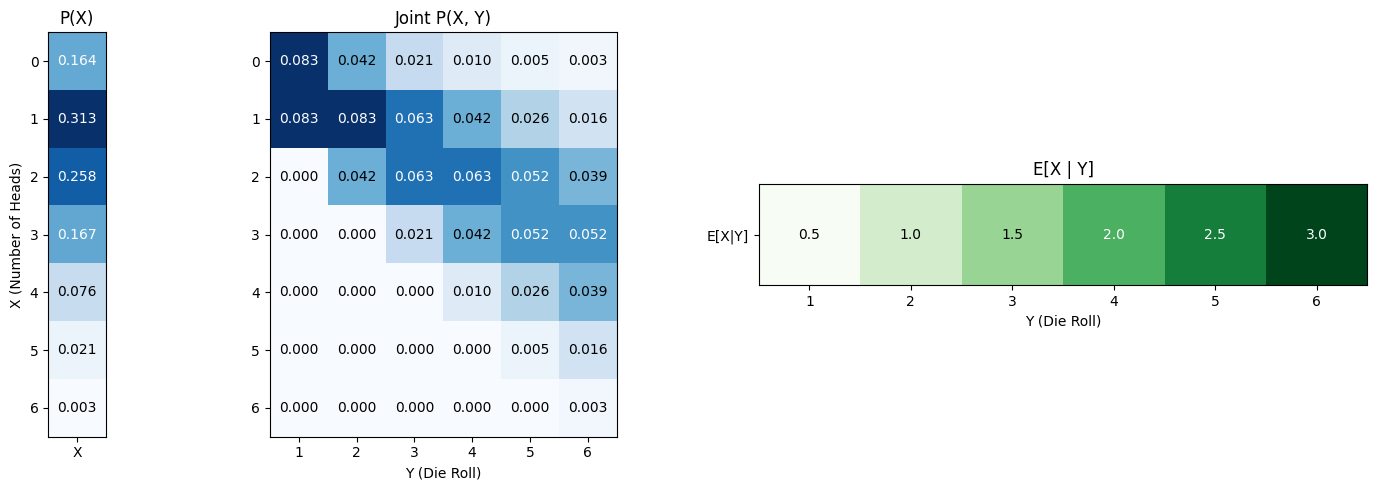

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# 1. Compute distributions
y_values = np.arange(1, 7)
x_values = np.arange(0, 7)

# Joint probability table P(X, Y)
joint_prob = np.zeros((len(x_values), len(y_values)))
for j, y in enumerate(y_values):
    for i, x in enumerate(x_values):
        if x <= y:
            joint_prob[i, j] = binom.pmf(x, y, 0.5) * (1/6)

# Marginal probability table P(X) (single column)
marginal_x = np.sum(joint_prob, axis=1).reshape(-1, 1)

# Marginal conditional expectation table E(X|Y) (single row)
cond_exp = (y_values / 2).reshape(1, -1)

# 2. Setup figure and axes
fig, axes = plt.subplots(1, 3, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 6, 6]})

# Helper function to annotate heatmaps
def annotate_heatmap(im, data, ax, fmt="{:.3f}"):
    threshold = data.max() / 2.
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            color = "white" if data[i, j] > threshold else "black"
            ax.text(j, i, fmt.format(data[i, j]), ha="center", va="center", color=color)

# Subplot 1: Marginal P(X)
axes[0].imshow(marginal_x, cmap='Blues')
axes[0].set_title("P(X)")
axes[0].set_yticks(np.arange(len(x_values)))
axes[0].set_yticklabels(x_values)
axes[0].set_xticks([0])
axes[0].set_xticklabels(["X"])
axes[0].set_ylabel("X (Number of Heads)")
annotate_heatmap(None, marginal_x, axes[0])

# Subplot 2: Joint P(X, Y)
axes[1].imshow(joint_prob, cmap='Blues')
axes[1].set_title("Joint P(X, Y)")
axes[1].set_yticks(np.arange(len(x_values)))
axes[1].set_yticklabels(x_values)
axes[1].set_xticks(np.arange(len(y_values)))
axes[1].set_xticklabels(y_values)
axes[1].set_xlabel("Y (Die Roll)")
annotate_heatmap(None, joint_prob, axes[1])

# Subplot 3: E[X | Y]
axes[2].imshow(cond_exp, cmap='Greens')
axes[2].set_title("E[X | Y]")
axes[2].set_yticks([0])
axes[2].set_yticklabels(["E[X|Y]"])
axes[2].set_xticks(np.arange(len(y_values)))
axes[2].set_xticklabels(y_values)
axes[2].set_xlabel("Y (Die Roll)")
annotate_heatmap(None, cond_exp, axes[2], fmt="{:.1f}")

plt.tight_layout()
plt.show()

## Example: Population Sizes

Assume a population of animals has an initial generation of $X_0$ female individuals, and, subsequently, every female gives rise to an independent number of female offspring following a Poisson distribution with rate $\lambda$, creating generations $X_1, X_2,\dots, X_n$. What is the expected number $\mathbb{E}(X_n)$ of females in the $n$-th generation?

Let us start a 

In [119]:
def simulate_population(x0, n, rate, reps=10, seed=None):
    rng = np.random.default_rng(seed)
    res = np.zeros((reps, n+1), dtype='int')
    res[:, 0] = x0
    for r in range(reps):
        for i in range(1, n+1):
            offspring = rng.poisson(rate, size=res[r, i-1])
            res[r, i] = offspring.sum()
    return res

simulate_population(2, 10, 1.5, 1)



array([[ 2,  4,  3,  4, 10,  9, 14, 16, 27, 43, 70]])

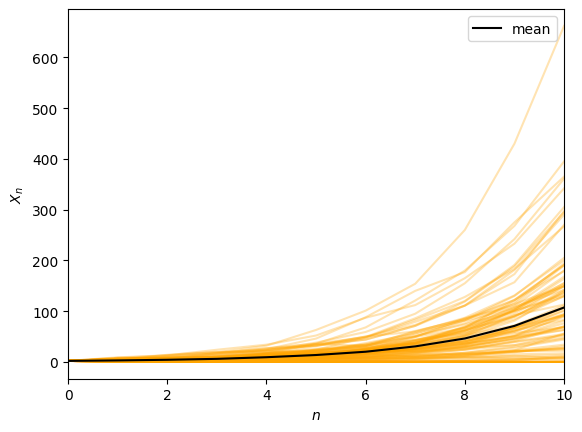

In [140]:
from matplotlib import pyplot as plt

pops = simulate_population(2, 10, 1.5, 100, seed=0)
for pop in pops:
    plt.plot(pop, color='orange', alpha=0.3)
plt.plot(pops.mean(axis=0), color='black', label='mean')
plt.margins(x=0)
plt.ylabel('$X_n$')
plt.xlabel('$n$')
plt.legend()
plt.show()

### Expected Value

$$
\begin{aligned}
\mathbb{E}(X_n) &= \mathbb{E} \mathbb{E}(X_n \mid X_{n-1})\\
&= \mathbb{E} \mathbb{E}(O_1 + \dots + O_{X_{n-1}} \mid X_{n-1})\\
&= \lambda \mathbb{E}(X_{n-1})
\end{aligned}
$$